# CP5 · Notebook 04 — Baselines

Antes de entrenar DQN, establecemos referencias:
1. **Agente aleatorio** (ya visto en 03 — 10 episodios formales).
2. **Rule-based** simple (heurística): "siempre acelera, cambia carril si hay coche delante cercano".

~5 min.

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
import gymnasium as gym
import highway_env
from pathlib import Path
OUT = Path('../outputs'); OUT.mkdir(exist_ok=True)

def make_env(seed=0):
    env = gym.make('highway-v0', config={
        'observation': {'type': 'Kinematics', 'vehicles_count': 5,
                         'features': ['presence','x','y','vx','vy'], 'normalize': True},
        'action': {'type': 'DiscreteMetaAction'},
        'lanes_count': 4, 'vehicles_count': 20, 'duration': 40,
        'policy_frequency': 5,
    })
    env.reset(seed=seed)
    return env

ACTIONS = {0: 'LANE_LEFT', 1: 'IDLE', 2: 'LANE_RIGHT', 3: 'FASTER', 4: 'SLOWER'}

objc[41873]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x1121ccbf8) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1127cc9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[41873]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x1121ccc48) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1127cca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[41873]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib 

## 1. Función de evaluación

In [2]:
def evaluate(policy_fn, n_episodes=20, seed_base=1000, label=''):
    """policy_fn(obs, info) → action_id. Devuelve dict con métricas."""
    returns, durations, crashes = [], [], []
    for ep in range(n_episodes):
        env = make_env(seed=seed_base + ep)
        obs, info = env.reset(seed=seed_base + ep)
        ep_return, steps, crashed = 0.0, 0, False
        while True:
            a = policy_fn(obs, info)
            obs, r, done, trunc, info = env.step(a)
            ep_return += r; steps += 1
            if done or trunc:
                crashed = info.get('crashed', False); break
        env.close()
        returns.append(ep_return); durations.append(steps); crashes.append(crashed)
    return {
        'label': label,
        'n_episodes': n_episodes,
        'mean_return': float(np.mean(returns)),
        'std_return':  float(np.std(returns)),
        'mean_duration': float(np.mean(durations)),
        'crash_rate':  float(sum(crashes) / n_episodes),
        'returns_per_ep': [float(r) for r in returns],
    }

## 2. Baseline 1 — agente aleatorio

In [3]:
rng_local = np.random.default_rng(0)
def random_policy(obs, info):
    return int(rng_local.integers(0, 5))

random_stats = evaluate(random_policy, n_episodes=20, label='random')
print(f'RANDOM (20 ep):')
print(f'  return  mean={random_stats["mean_return"]:.2f}  ± {random_stats["std_return"]:.2f}')
print(f'  duración media: {random_stats["mean_duration"]:.1f} steps')
print(f'  % colisión: {100*random_stats["crash_rate"]:.0f}%')

RANDOM (20 ep):
  return  mean=36.50  ± 24.32
  duración media: 45.7 steps
  % colisión: 100%


## 3. Baseline 2 — rule-based

Política heurística:
- Por defecto, **acelera** (FASTER).
- Si hay coche delante muy cerca (dx normalizado < 0.15, dy ≈ 0) → **cambia al carril menos ocupado**.
- Si está en carril extremo y hay obstáculo → cambia al otro.

In [4]:
def rule_based_policy(obs, info):
    """obs shape (5, 5): ego primer row, 4 vecinos.
    Features: [presence, x_norm, y_norm, vx_norm, vy_norm]
    """
    ego_y = obs[0, 2]
    others = obs[1:]
    front_close = False
    for v in others:
        if v[0] < 0.5: continue
        dx, dy = v[1], v[2]
        if 0 < dx < 0.15 and abs(dy) < 0.04:
            front_close = True
            break
    if not front_close:
        return 3   # FASTER
    # Cambiar carril: a la derecha si está en izq/centro, a la izq si está más a la derecha
    return 2 if ego_y < 0 else 0

rule_stats = evaluate(rule_based_policy, n_episodes=20, label='rule_based')
print(f'RULE-BASED (20 ep):')
print(f'  return mean={rule_stats["mean_return"]:.2f}  ± {rule_stats["std_return"]:.2f}')
print(f'  duración media: {rule_stats["mean_duration"]:.1f} steps')
print(f'  % colisión: {100*rule_stats["crash_rate"]:.0f}%')

RULE-BASED (20 ep):
  return mean=79.35  ± 55.86
  duración media: 84.4 steps
  % colisión: 90%


## 4. Comparación visual

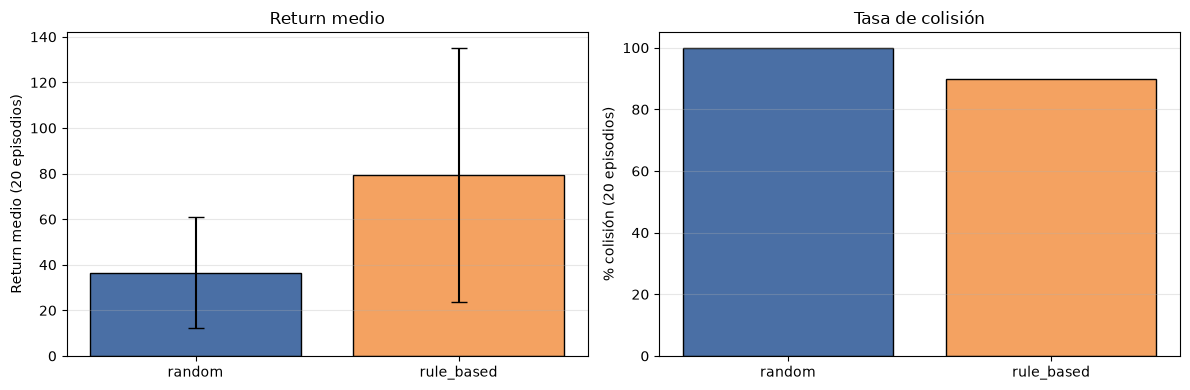

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['random', 'rule_based'],
             [random_stats['mean_return'], rule_stats['mean_return']],
             yerr=[random_stats['std_return'], rule_stats['std_return']],
             color=['#4a6fa5', '#f4a261'], edgecolor='black', capsize=6)
axes[0].set_ylabel('Return medio (20 episodios)')
axes[0].set_title('Return medio')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(['random', 'rule_based'],
             [100*random_stats['crash_rate'], 100*rule_stats['crash_rate']],
             color=['#4a6fa5', '#f4a261'], edgecolor='black')
axes[1].set_ylabel('% colisión (20 episodios)')
axes[1].set_title('Tasa de colisión')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.savefig(OUT / '04_baselines.png', dpi=100, bbox_inches='tight'); plt.show()

In [6]:
with open(OUT / '04_baselines.json', 'w') as f:
    json.dump({'random': random_stats, 'rule_based': rule_stats}, f, indent=2)
print('✅ Baselines guardadas. Tu DQN tendrá que superar al menos el rule-based para considerarse aprendido.')
print(f'   Target a batir: return medio > {rule_stats["mean_return"]:.1f}')
print('\nVe a 05_dqn_entrenamiento.ipynb.')

✅ Baselines guardadas. Tu DQN tendrá que superar al menos el rule-based para considerarse aprendido.
   Target a batir: return medio > 79.4

Ve a 05_dqn_entrenamiento.ipynb.
